In [2]:
import numpy as np
import pandas as pd
from pandas import Series,DataFrame
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = np.loadtxt("data.txt", delimiter=" ")
X = df[ :,0]
y = df[:,1]
m = len(y)

In [4]:
X = X.reshape(m,1)
y = y.reshape(m,1)
X = np.hstack([np.ones((m, 1)), X])
theta = np.zeros((2, 1))

In [5]:
X

array([[1.000e+00, 2.104e+03],
       [1.000e+00, 1.600e+03],
       [1.000e+00, 2.400e+03],
       [1.000e+00, 1.416e+03],
       [1.000e+00, 3.000e+03],
       [1.000e+00, 1.985e+03],
       [1.000e+00, 1.534e+03],
       [1.000e+00, 1.427e+03],
       [1.000e+00, 1.380e+03],
       [1.000e+00, 1.494e+03]])

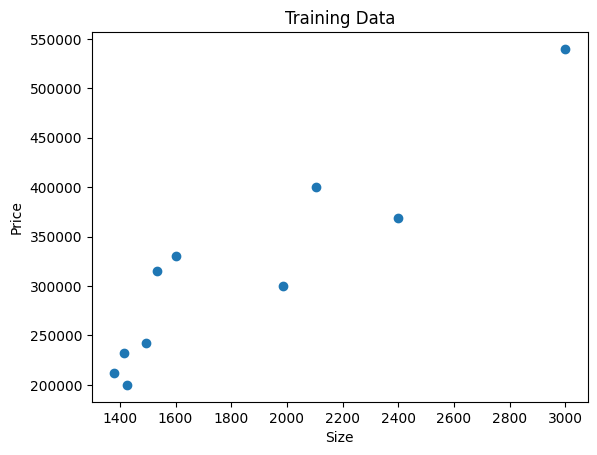

In [6]:
plt.scatter(X[:,1], y)
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Training Data")
plt.show()


In [7]:
def cost(X,y, theta):
    m = len(y)
    predictions = X.dot(theta)
    sq_error = (predictions - y) ** 2
    return (1 / (2*m)) * np.sum(sq_error)

In [8]:
print("Initial cost:", cost(X, y, theta))


Initial cost: 54152165500.0


In [9]:
X_raw = df[:,0].reshape(-1, 1)

mu = np.mean(X_raw)
sigma = np.std(X_raw)
X_norm = (X_raw - mu) / sigma

X = np.hstack([np.ones((m,1)), X_norm])


In [17]:
def GD(X,y, theta, alpha , iter):
    m = len(y)
    j_hist = []

    for i in range(iter):
        predictions = X.dot(theta)
        theta = theta - (alpha / m) * (X.T.dot(predictions - y))
        j_hist.append(cost(X,y,theta))

    return theta,j_hist

alpha = 0.0001
iters = 200000
theta, j_hist = GD(X, y, theta, alpha, iters)

print("Theta after training:", theta)

Theta after training: [[313989.99999971]
 [ 91096.93357693]]


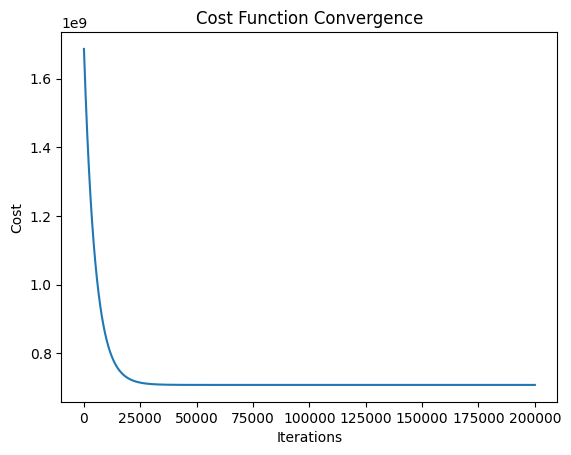

In [14]:
plt.plot(j_hist)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function Convergence")
plt.show()


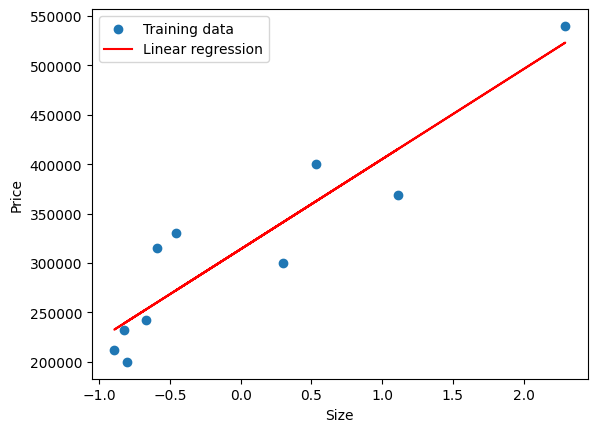

In [15]:
plt.scatter(X[:,1], y, label="Training data")
plt.plot(X[:,1], X.dot(theta), 'r', label="Linear regression")
plt.xlabel("Size")
plt.ylabel("Price")
plt.legend()
plt.show()
